# NB02 — Where Does the OLS Formula Come From?

> **StatQuest principle: show the derivation step by step so it's never a black box.**

---

## The main ideas are:

1. SSR is a function of b0 and b1 — it's a **bowl-shaped surface**
2. At the lowest point of the bowl, the **slope** (derivative) is **zero**
3. Setting both partial derivatives to zero gives us two equations
4. Solving those two equations gives the formulas for b0 and b1


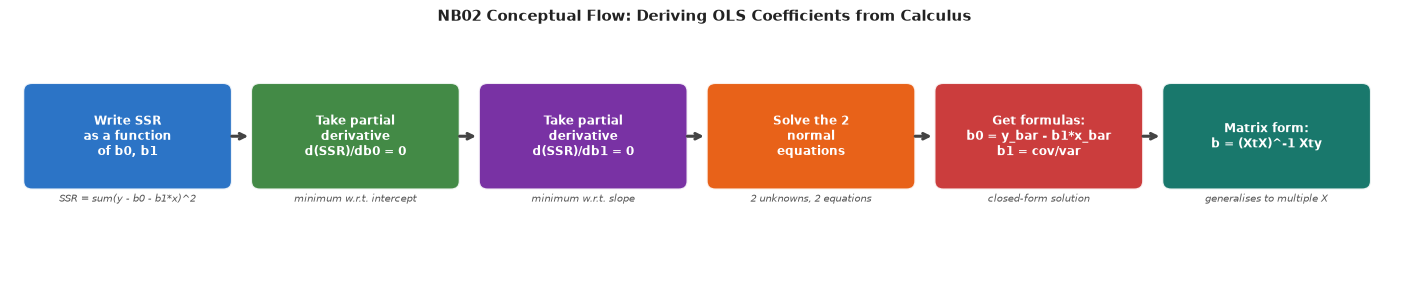

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

def flow_diagram(steps, title, colors=None, notes=None, figsize=(14, 2.8)):
    """Draw a horizontal flow diagram.  steps = list of strings."""
    n = len(steps)
    default_colors = [
        '#1565C0','#2E7D32','#E65100','#6A1B9A',
        '#00695C','#AD1457','#37474F','#4E342E',
        '#0277BD','#558B2F',
    ]
    colors = (colors or default_colors[:n]) + default_colors
    notes  = notes or [''] * n

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-0.3, n * 3.1)
    ax.set_ylim(-1.2, 2.4)
    ax.axis('off')

    bw, bh = 2.6, 1.3
    for i, (step, color, note) in enumerate(zip(steps, colors, notes)):
        x = i * 3.1
        box = FancyBboxPatch((x, 0.2), bw, bh,
                             boxstyle="round,pad=0.12",
                             facecolor=color, edgecolor='white', linewidth=1.5, alpha=0.90)
        ax.add_patch(box)
        ax.text(x + bw/2, 0.2 + bh/2, step,
                ha='center', va='center', fontsize=8.5,
                color='white', fontweight='bold', multialignment='center')
        if note:
            ax.text(x + bw/2, 0.02, note,
                    ha='center', va='top', fontsize=7, color='#555', style='italic')
        if i < n - 1:
            ax.annotate('',
                xy=(x + bw + 0.38, 0.2 + bh/2),
                xytext=(x + bw + 0.08, 0.2 + bh/2),
                arrowprops=dict(arrowstyle='->', color='#444', lw=2.2))

    ax.set_title(title, fontsize=11, fontweight='bold', pad=6, color='#222')
    plt.tight_layout(pad=0.4)
    plt.show()

flow_diagram(
    steps=[
        'Write SSR\nas a function\nof b0, b1',
        'Take partial\nderivative\nd(SSR)/db0 = 0',
        'Take partial\nderivative\nd(SSR)/db1 = 0',
        'Solve the 2\nnormal\nequations',
        'Get formulas:\nb0 = y_bar - b1*x_bar\nb1 = cov/var',
        'Matrix form:\nb = (XtX)^-1 Xty',
    ],
    notes=[
        'SSR = sum(y - b0 - b1*x)^2',
        'minimum w.r.t. intercept',
        'minimum w.r.t. slope',
        '2 unknowns, 2 equations',
        'closed-form solution',
        'generalises to multiple X',
    ],
    title='NB02 Conceptual Flow: Deriving OLS Coefficients from Calculus',
    colors=['#1565C0','#2E7D32','#6A1B9A','#E65100','#C62828','#00695C'],
)


## Step 1 — The SSR surface

SSR is a function of two unknowns: b0 and b1.

```
SSR(b0, b1) = sum_i ( y_i - b0 - b1*x_i )^2
```

Imagine a bowl: every (b0, b1) combination gives one SSR value.
The bowl has exactly ONE minimum — that's the OLS solution.


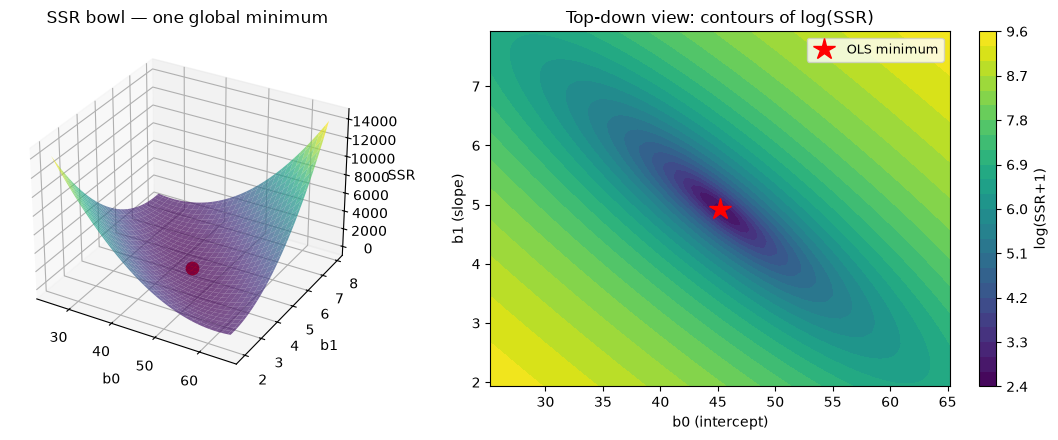

The red star = OLS solution = the lowest point of the bowl


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

hours  = np.array([1.,2.,3.,4.,5.,6.,7.,8.,9.,10.])
scores = np.array([50.,53.,61.,67.,70.,75.,79.,84.,89.,95.])

xbar = hours.mean();  ybar = scores.mean()
b1_ols = np.sum((hours-xbar)*(scores-ybar)) / np.sum((hours-xbar)**2)
b0_ols = ybar - b1_ols*xbar

# SSR on a grid
b0_grid = np.linspace(b0_ols - 20, b0_ols + 20, 60)
b1_grid = np.linspace(b1_ols - 3,  b1_ols + 3,  60)
B0, B1  = np.meshgrid(b0_grid, b1_grid)
SSR     = np.sum((scores - (B0[:,:,None] + B1[:,:,None]*hours[None,None,:]))**2, axis=2)

fig = plt.figure(figsize=(12, 4.5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(B0, B1, SSR, cmap='viridis', alpha=0.7)
ax1.scatter([b0_ols], [b1_ols], [np.min(SSR)], color='red', s=80, zorder=5)
ax1.set_xlabel('b0'); ax1.set_ylabel('b1'); ax1.set_zlabel('SSR')
ax1.set_title('SSR bowl — one global minimum')

ax2 = fig.add_subplot(122)
cp = ax2.contourf(B0, B1, np.log(SSR+1), levels=25, cmap='viridis')
ax2.plot(b0_ols, b1_ols, 'r*', markersize=16, label='OLS minimum')
ax2.set_xlabel('b0 (intercept)'); ax2.set_ylabel('b1 (slope)')
ax2.set_title('Top-down view: contours of log(SSR)')
plt.colorbar(cp, ax=ax2, label='log(SSR+1)')
ax2.legend(fontsize=9)

plt.tight_layout(); plt.show()
print("The red star = OLS solution = the lowest point of the bowl")


## Step 2 — Partial derivative with respect to b0

At the minimum, changing b0 by a tiny amount should NOT change SSR.
That means the partial derivative is zero:

```
d(SSR)/d(b0) = -2 * sum(y_i - b0 - b1*x_i) = 0

=> sum(y_i) = n*b0 + b1*sum(x_i)

=> b0 = y_bar - b1 * x_bar       <-- intercept formula
```

**Plain-English insight:** the regression line ALWAYS passes through the point (x_bar, y_bar).
The average point is always ON the line — guaranteed.


## Step 3 — Partial derivative with respect to b1

Similarly for b1:

```
d(SSR)/d(b1) = -2 * sum( x_i*(y_i - b0 - b1*x_i) ) = 0

Substitute b0 = y_bar - b1*x_bar and simplify:

=> b1 = sum[(x_i - x_bar)(y_i - y_bar)]  /  sum[(x_i - x_bar)^2]

     = Cov(x, y)  /  Var(x)       <-- slope formula
```

**Plain-English insight:** the slope equals how much x and y move together (covariance), divided by how spread out x is (variance). If x and y move together a lot relative to x's spread -> steep slope.


In [3]:
import numpy as np

X = np.array([1.,2.,3.,4.,5.])
y = np.array([2.,4.,5.,4.,5.])

xbar, ybar = X.mean(), y.mean()

# Every intermediate value shown
print(f"x_bar = {xbar:.2f},  y_bar = {ybar:.2f}")
print(f"{'x':>4} {'y':>4} {'x-xb':>6} {'y-yb':>6} {'(x-xb)(y-yb)':>14} {'(x-xb)^2':>10}")
print("-"*55)
num = 0; den = 0
for xi, yi in zip(X, y):
    xd, yd = xi-xbar, yi-ybar
    num += xd*yd; den += xd**2
    print(f"{xi:>4.0f} {yi:>4.0f} {xd:>6.2f} {yd:>6.2f} {xd*yd:>14.4f} {xd**2:>10.4f}")
print("-"*55)
print(f"{'Sum':>24} {num:>14.4f} {den:>10.4f}")
b1 = num/den;  b0 = ybar - b1*xbar
print(f"\nb1 = {num:.4f} / {den:.4f} = {b1:.6f}")
print(f"b0 = {ybar:.4f} - {b1:.4f}*{xbar:.4f} = {b0:.6f}")


x_bar = 3.00,  y_bar = 4.00
   x    y   x-xb   y-yb   (x-xb)(y-yb)   (x-xb)^2
-------------------------------------------------------
   1    2  -2.00  -2.00         4.0000     4.0000
   2    4  -1.00   0.00        -0.0000     1.0000
   3    5   0.00   1.00         0.0000     0.0000
   4    4   1.00   0.00         0.0000     1.0000
   5    5   2.00   1.00         2.0000     4.0000
-------------------------------------------------------
                     Sum         6.0000    10.0000

b1 = 6.0000 / 10.0000 = 0.600000
b0 = 4.0000 - 0.6000*3.0000 = 2.200000


## Step 4 — Matrix form (generalises to multiple X)

For multiple predictors, the same calculus gives:

```
Normal equations:  (X^T X) b = X^T y

Solution:  b_hat = (X^T X)^-1  X^T y
```

**X** is called the **design matrix**: one row per observation, one column per predictor, plus a column of 1s for the intercept.

The column of 1s captures b0 — that's why we add it.


In [4]:
import numpy as np

X_raw = np.array([1.,2.,3.,4.,5.])
y     = np.array([2.,4.,5.,4.,5.])

# Design matrix: prepend a column of 1s
X_design = np.column_stack([np.ones(len(X_raw)), X_raw])
print("Design matrix X:")
print(X_design)

# Normal equations
XtX  = X_design.T @ X_design   # (X^T)(X) — 2x2 matrix
Xty  = X_design.T @ y          # (X^T)(y) — 2x1 vector
beta = np.linalg.solve(XtX, Xty)   # solve vs inv() — numerically safer

print(f"\n(X^T X) =\n{XtX}")
print(f"\n(X^T y) = {Xty}")
print(f"\nb_hat = [b0, b1] = {beta}")
print(f"\nSame as formulas above: b0={b0:.6f}, b1={b1:.6f}")
print(f"Match: {np.allclose(beta, [b0, b1])}")


Design matrix X:
[[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]]

(X^T X) =
[[ 5. 15.]
 [15. 55.]]

(X^T y) = [20. 66.]

b_hat = [b0, b1] = [2.2 0.6]

Same as formulas above: b0=2.200000, b1=0.600000
Match: True


## Key Takeaways

| Result | Formula | Intuition |
|--------|---------|-----------|
| Intercept | b0 = y_bar - b1*x_bar | line passes through (x_bar, y_bar) |
| Slope | b1 = Cov(x,y) / Var(x) | how much x and y co-vary, scaled by x's spread |
| Matrix form | b = (XtX)^-1 Xty | generalises to any number of predictors |
| Uniqueness | SSR bowl has one minimum | OLS solution is always unique (if X has full rank) |

**Next: NB03 — implement everything from scratch in pure Python.**
